# Análisis de Sincronización: Hilbert + Kuramoto + Joint Recurrence Plots

Objetivo: Identificar el desfase temporal óptimo entre FormacionMWEntT11TempPV y FormacionMWSalT12TempPV
usando:
1. Transformada de Hilbert + Parámetro de orden de Kuramoto (sincronización de fase)
2. Joint Recurrence Plots (sincronización de estados en espacio de fase)

---
**Criterio de desfase óptimo (Kuramoto):** Longest Continuous Sync Segment (`max_sustained_sec`)

El score de Kuramoto se calcula como la normalización del segmento continuo más largo
donde el parámetro de orden r > 0.7 (sincronización de fase fuerte).

**Criterio de desfase óptimo (JRP):** Score combinado RR × DET × max_diag

**Score combinado:** Media aritmética de ambos scores normalizados

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.signal import hilbert
from scipy.ndimage import uniform_filter1d
from scipy.spatial.distance import pdist, squareform

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

# Load data
df = pd.read_parquet('../data/datos_ind.pqt')
df['fecha'] = pd.to_datetime(df['fecha'])
df = df.set_index('fecha')
print(f'Shape: {df.shape}')
print(f'Date range: {df.index.min()} to {df.index.max()}')

Shape: (24383269, 10)
Date range: 2021-01-03 01:35:46.772000 to 2021-12-23 00:00:00.287000


In [22]:
# Select temporal window
start_time = '2021-11-03 19:00:00'
end_time = '2021-11-03 19:30:00'

df_hour = df.loc[start_time:end_time].copy()
print(f'Window: {df_hour.index[0]} to {df_hour.index[-1]}')
print(f'Length: {len(df_hour)} samples')

s1 = pd.Series(df_hour['FormacionMWSalT12TempPV'].values).interpolate().values
s2 = pd.Series(df_hour['FormacionMWEntT11TempPV'].values).interpolate().values

# Normalize to [-1, 1] centered at 0
def normalize_zero_centered(x):
    x = np.asarray(x, dtype=float)
    x_centered = x - np.mean(x)
    max_abs = np.max(np.abs(x_centered))
    if max_abs > 0:
        return x_centered / max_abs
    return x_centered

# Apply smoothing (moving average) to reduce noise
def smooth_signal(x, window=5):
    """Apply moving average smoothing."""
    return uniform_filter1d(x, size=window, mode='reflect')

s1_norm = normalize_zero_centered(s1)
s2_norm = normalize_zero_centered(s2)

# Apply smoothing for JRP analysis
smooth_window = 5  # smoothing window in samples
s1_smooth = smooth_signal(s1_norm, window=smooth_window)
s2_smooth = smooth_signal(s2_norm, window=smooth_window)

time_axis = np.arange(len(s1_norm))

Window: 2021-11-03 19:00:00.363000 to 2021-11-03 19:30:00.977000
Length: 1800 samples


In [23]:
# --- HILBERT + KURAMOTO FUNCTIONS ---
def get_phase(signal):
    analytic = hilbert(signal)
    return np.angle(analytic)

def kuramoto_order_param(phi1, phi2):
    z = 0.5 * (np.exp(1j * phi1) + np.exp(1j * phi2))
    return np.abs(z)

# --- JOINT RECURRENCE PLOT FUNCTIONS ---
def embed_time_series(x, m=3, tau=1):
    """Time-delay embedding."""
    n = len(x)
    if n < (m - 1) * tau + 1:
        return np.array([])
    embedded = np.zeros((n - (m - 1) * tau, m))
    for i in range(m):
        embedded[:, i] = x[i * tau:n - (m - 1 - i) * tau]
    return embedded

def recurrence_plot(x, threshold=None, rate=0.05):
    """Compute recurrence plot for a single time series."""
    n = len(x)
    if x.ndim == 1:
        x = x.reshape(-1, 1)
    dists = squareform(pdist(x, metric='euclidean'))
    
    if threshold is None:
        # Fixed recurrence rate threshold
        flat_dists = dists[np.triu_indices(n, k=1)]
        threshold = np.percentile(flat_dists, rate * 100)
    
    rp = dists <= threshold
    return rp, threshold

def joint_recurrence_plot(rp1, rp2):
    """Compute Joint Recurrence Plot: JRP = RP1 AND RP2."""
    return rp1 & rp2

def jrp_rqa_metrics(jrp):
    """Compute RQA metrics from Joint Recurrence Plot."""
    n = jrp.shape[0]
    
    # Recurrence Rate (RR)
    rr = np.sum(jrp) / (n * n)
    
    # Determinism (DET) - fraction of recurrence points forming diagonal lines
    diag_lengths = []
    for offset in range(-n + 1, n):
        diag = np.diag(jrp, k=offset)
        if len(diag) < 2:
            continue
        in_line = False
        length = 0
        for val in diag:
            if val:
                if not in_line:
                    in_line = True
                    length = 1
                else:
                    length += 1
            else:
                if in_line and length >= 2:
                    diag_lengths.append(length)
                in_line = False
                length = 0
        if in_line and length >= 2:
            diag_lengths.append(length)
    
    if len(diag_lengths) > 0:
        det = np.sum(diag_lengths) / np.sum(jrp)
        max_diag = np.max(diag_lengths)
        mean_diag = np.mean(diag_lengths)
    else:
        det = 0
        max_diag = 0
        mean_diag = 0
    
    # Laminarity (LAM) - vertical lines
    vert_lengths = []
    for col in range(n):
        in_line = False
        length = 0
        for row in range(n):
            if jrp[row, col]:
                if not in_line:
                    in_line = True
                    length = 1
                else:
                    length += 1
            else:
                if in_line and length >= 2:
                    vert_lengths.append(length)
                in_line = False
                length = 0
        if in_line and length >= 2:
            vert_lengths.append(length)
    
    if len(vert_lengths) > 0:
        lam = np.sum(vert_lengths) / np.sum(jrp)
        max_vert = np.max(vert_lengths)
    else:
        lam = 0
        max_vert = 0
    
    return {
        'RR': rr,
        'DET': det,
        'LAM': lam,
        'max_diag': max_diag,
        'mean_diag': mean_diag,
        'max_vert': max_vert
    }

Embedded shapes: s1=(1798, 3), s2=(1798, 3)
Thresholds: th1=0.0543, th2=0.1439
JRP Metrics (lag=0): RR=0.0123, DET=0.7778, LAM=0.8014
  max_diag=1798, mean_diag=3.3, max_vert=17


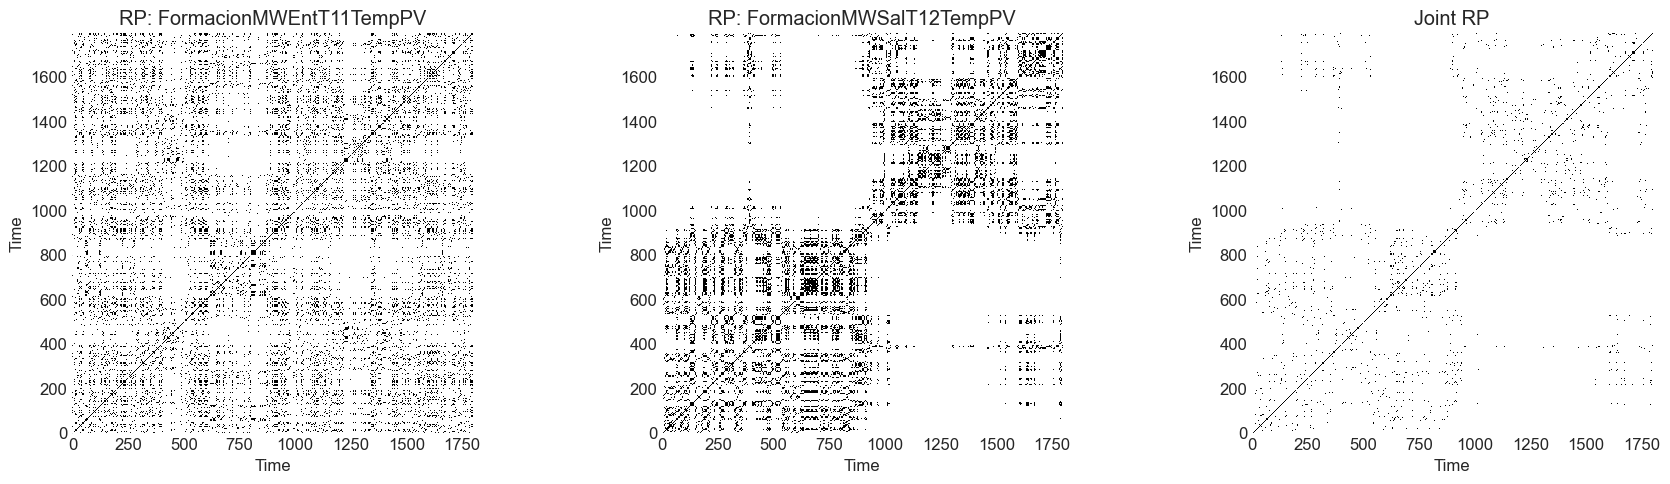

In [24]:
# Test JRP at lag=0
m, tau = 3, 1
s1_emb = embed_time_series(s1_smooth, m=m, tau=tau)
s2_emb = embed_time_series(s2_smooth, m=m, tau=tau)

print(f'Embedded shapes: s1={s1_emb.shape}, s2={s2_emb.shape}')

rp1, thresh1 = recurrence_plot(s1_emb, rate=0.1)
rp2, thresh2 = recurrence_plot(s2_emb, rate=0.1)
jrp = joint_recurrence_plot(rp1, rp2)

metrics = jrp_rqa_metrics(jrp)
print(f'Thresholds: th1={thresh1:.4f}, th2={thresh2:.4f}')
print(f'JRP Metrics (lag=0): RR={metrics["RR"]:.4f}, DET={metrics["DET"]:.4f}, LAM={metrics["LAM"]:.4f}')
print(f'  max_diag={metrics["max_diag"]}, mean_diag={metrics["mean_diag"]:.1f}, max_vert={metrics["max_vert"]}')

# Plot RPs and JRP
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, rp, title in zip(axes, [rp1, rp2, jrp], ['RP: FormacionMWEntT11TempPV', 'RP: FormacionMWSalT12TempPV', 'Joint RP']):
    ax.imshow(rp.T, origin='lower', cmap='binary', aspect='equal', interpolation='nearest')
    ax.set_title(title)
    ax.set_xlabel('Time')
    ax.set_ylabel('Time')
plt.tight_layout()
plt.show()

In [25]:
# Sweep lags with both Kuramoto and JRP metrics
max_lag = 150
lag_step = 1
lags = np.arange(-max_lag, max_lag + 1, lag_step)

results = []

# Pre-compute s1_emb using smoothed signal (s1 doesn't shift)
m, tau = 3, 1
s1_emb = embed_time_series(s1_smooth, m=m, tau=tau)

for lag in lags:
    # Shift s2
    if lag > 0:
        s2_shifted = np.concatenate([np.full(lag, np.nan), s2_norm[:-lag]])
    elif lag < 0:
        s2_shifted = np.concatenate([s2_norm[-lag:], np.full(-lag, np.nan)])
    else:
        s2_shifted = s2_norm.copy()
    s2_shifted = pd.Series(s2_shifted).interpolate(limit_direction='both').values
    
    # --- KURAMOTO ---
    phi1 = get_phase(s1_norm)
    phi2 = get_phase(s2_shifted)
    r = kuramoto_order_param(phi1, phi2)
    
    r_mean = np.mean(r)
    r_std = np.std(r)
    threshold = 0.7
    frac_above = np.mean(r > threshold)
    above = r > threshold
    max_sustained = 0
    current = 0
    for val in above:
        if val:
            current += 1
            max_sustained = max(max_sustained, current)
        else:
            current = 0
    
    # --- JRP (only compute at coarser resolution for speed) ---
    jrp_metrics = {'RR': 0, 'DET': 0, 'LAM': 0, 'max_diag': 0}
    if lag % 10 == 0:  # Compute JRP every 10 seconds
        try:
            s2_emb = embed_time_series(s2_smooth, m=m, tau=tau)
            min_len = min(len(s1_emb), len(s2_emb))
            if min_len > 100:
                rp1, _ = recurrence_plot(s1_emb[:min_len], rate=0.1)
                rp2, _ = recurrence_plot(s2_emb[:min_len], rate=0.1)
                jrp = joint_recurrence_plot(rp1, rp2)
                jrp_metrics = jrp_rqa_metrics(jrp)
        except:
            pass
    
    results.append({
        'lag': lag,
        'r_mean': r_mean,
        'r_std': r_std,
        'frac_above_07': frac_above,
        'max_sustained_sec': max_sustained,
        'jrp_RR': jrp_metrics['RR'],
        'jrp_DET': jrp_metrics['DET'],
        'jrp_LAM': jrp_metrics['LAM'],
        'jrp_max_diag': jrp_metrics['max_diag']
    })
    
    if len(results) % 20 == 0:
        print(f'Processed {len(results)}/{len(lags)} lags...')

results_df = pd.DataFrame(results)
print('Done!')

Processed 20/301 lags...
Processed 40/301 lags...
Processed 60/301 lags...
Processed 80/301 lags...
Processed 100/301 lags...
Processed 120/301 lags...
Processed 140/301 lags...
Processed 160/301 lags...
Processed 180/301 lags...
Processed 200/301 lags...
Processed 220/301 lags...
Processed 240/301 lags...
Processed 260/301 lags...
Processed 280/301 lags...
Processed 300/301 lags...
Done!


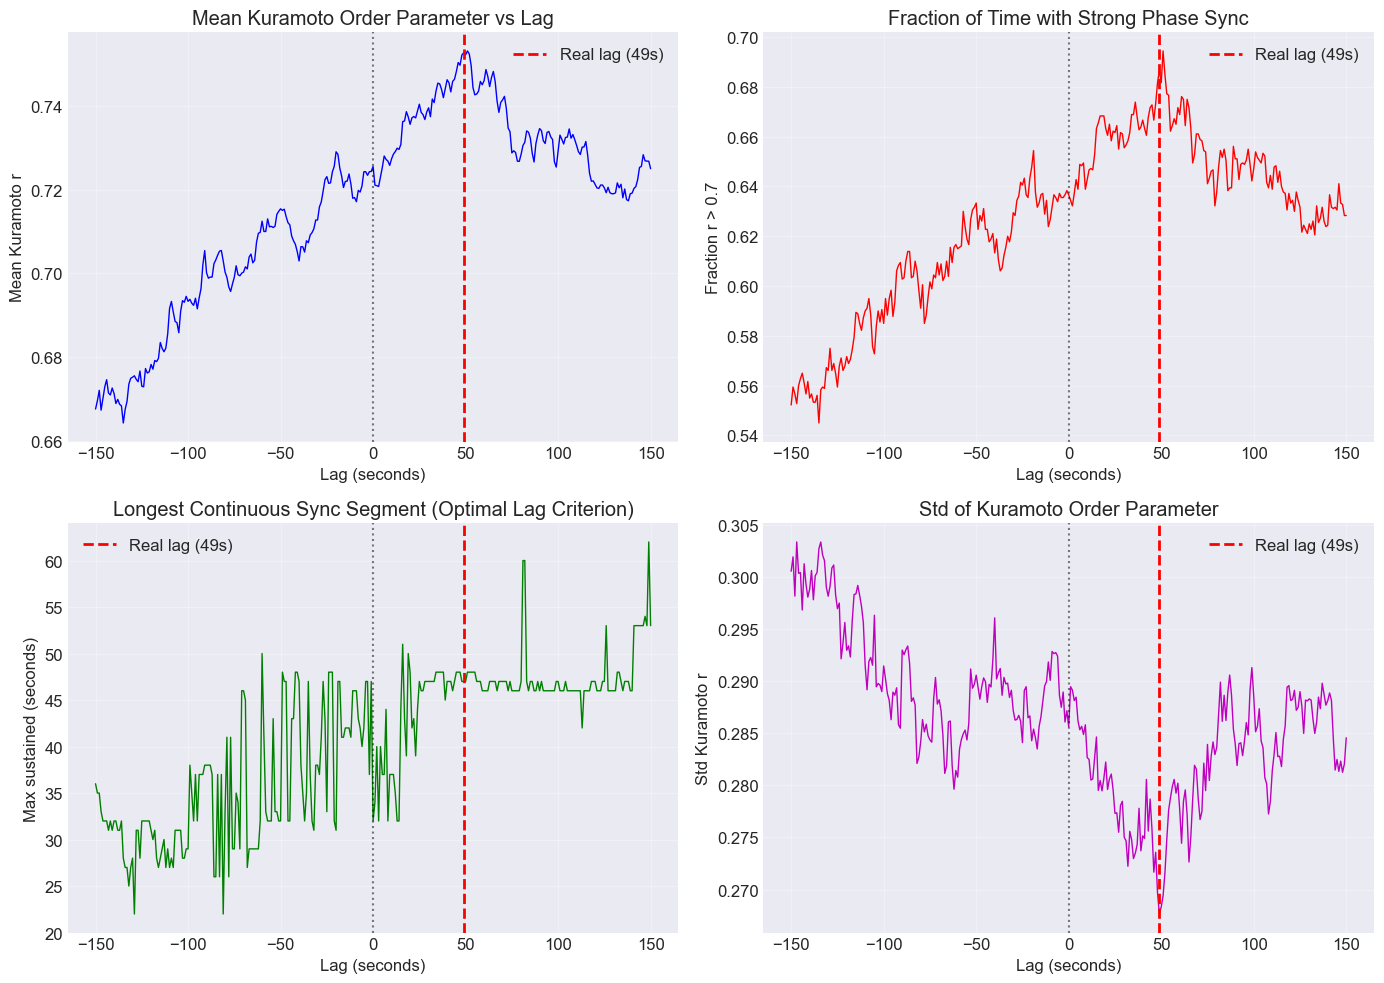

In [26]:
# Plot Kuramoto metrics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Real lag for marking
real_lag = int(18600 / df['FormacionVelocidad'].loc[start_time:end_time].mean())

axes[0, 0].plot(results_df['lag'], results_df['r_mean'], 'b-', linewidth=1)
axes[0, 0].set_xlabel('Lag (seconds)')
axes[0, 0].set_ylabel('Mean Kuramoto r')
axes[0, 0].set_title('Mean Kuramoto Order Parameter vs Lag')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].axvline(x=0, color='k', linestyle=':', alpha=0.5)
axes[0, 0].axvline(x=real_lag, color='red', linestyle='--', linewidth=2, label=f'Real lag ({real_lag}s)')
axes[0, 0].legend()

axes[0, 1].plot(results_df['lag'], results_df['frac_above_07'], 'r-', linewidth=1)
axes[0, 1].set_xlabel('Lag (seconds)')
axes[0, 1].set_ylabel('Fraction r > 0.7')
axes[0, 1].set_title('Fraction of Time with Strong Phase Sync')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].axvline(x=0, color='k', linestyle=':', alpha=0.5)
axes[0, 1].axvline(x=real_lag, color='red', linestyle='--', linewidth=2, label=f'Real lag ({real_lag}s)')
axes[0, 1].legend()

axes[1, 0].plot(results_df['lag'], results_df['max_sustained_sec'], 'g-', linewidth=1)
axes[1, 0].set_xlabel('Lag (seconds)')
axes[1, 0].set_ylabel('Max sustained (seconds)')
axes[1, 0].set_title('Longest Continuous Sync Segment (Optimal Lag Criterion)')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].axvline(x=0, color='k', linestyle=':', alpha=0.5)
axes[1, 0].axvline(x=real_lag, color='red', linestyle='--', linewidth=2, label=f'Real lag ({real_lag}s)')
axes[1, 0].legend()

axes[1, 1].plot(results_df['lag'], results_df['r_std'], 'm-', linewidth=1)
axes[1, 1].set_xlabel('Lag (seconds)')
axes[1, 1].set_ylabel('Std Kuramoto r')
axes[1, 1].set_title('Std of Kuramoto Order Parameter')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].axvline(x=0, color='k', linestyle=':', alpha=0.5)
axes[1, 1].axvline(x=real_lag, color='red', linestyle='--', linewidth=2, label=f'Real lag ({real_lag}s)')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

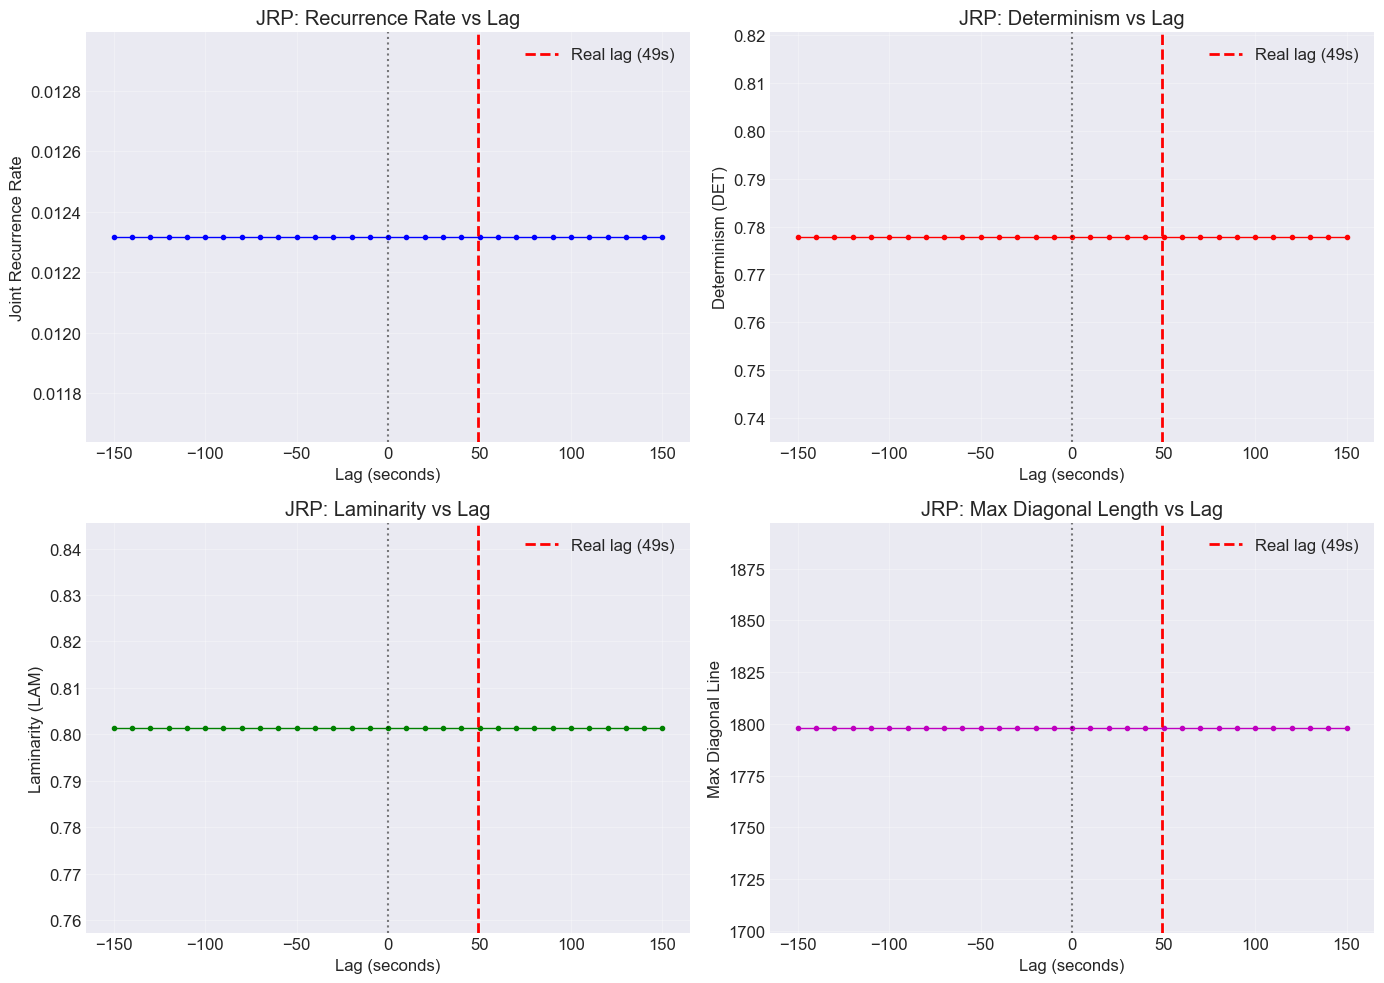

In [27]:
# Plot JRP metrics (only computed every 50s)
jrp_df = results_df[results_df['jrp_RR'] > 0].copy()

# Real lag for marking
real_lag = int(18600 / df['FormacionVelocidad'].loc[start_time:end_time].mean())

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(jrp_df['lag'], jrp_df['jrp_RR'], 'b-o', linewidth=1, markersize=3)
axes[0, 0].set_xlabel('Lag (seconds)')
axes[0, 0].set_ylabel('Joint Recurrence Rate')
axes[0, 0].set_title('JRP: Recurrence Rate vs Lag')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].axvline(x=0, color='k', linestyle=':', alpha=0.5)
axes[0, 0].axvline(x=real_lag, color='red', linestyle='--', linewidth=2, label=f'Real lag ({real_lag}s)')
axes[0, 0].legend()

axes[0, 1].plot(jrp_df['lag'], jrp_df['jrp_DET'], 'r-o', linewidth=1, markersize=3)
axes[0, 1].set_xlabel('Lag (seconds)')
axes[0, 1].set_ylabel('Determinism (DET)')
axes[0, 1].set_title('JRP: Determinism vs Lag')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].axvline(x=0, color='k', linestyle=':', alpha=0.5)
axes[0, 1].axvline(x=real_lag, color='red', linestyle='--', linewidth=2, label=f'Real lag ({real_lag}s)')
axes[0, 1].legend()

axes[1, 0].plot(jrp_df['lag'], jrp_df['jrp_LAM'], 'g-o', linewidth=1, markersize=3)
axes[1, 0].set_xlabel('Lag (seconds)')
axes[1, 0].set_ylabel('Laminarity (LAM)')
axes[1, 0].set_title('JRP: Laminarity vs Lag')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].axvline(x=0, color='k', linestyle=':', alpha=0.5)
axes[1, 0].axvline(x=real_lag, color='red', linestyle='--', linewidth=2, label=f'Real lag ({real_lag}s)')
axes[1, 0].legend()

axes[1, 1].plot(jrp_df['lag'], jrp_df['jrp_max_diag'], 'm-o', linewidth=1, markersize=3)
axes[1, 1].set_xlabel('Lag (seconds)')
axes[1, 1].set_ylabel('Max Diagonal Line')
axes[1, 1].set_title('JRP: Max Diagonal Length vs Lag')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].axvline(x=0, color='k', linestyle=':', alpha=0.5)
axes[1, 1].axvline(x=real_lag, color='red', linestyle='--', linewidth=2, label=f'Real lag ({real_lag}s)')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

In [28]:
# Combined analysis: Find optimal lag from both methods
# KURAMOTO: Use 'Fraction of time with strong phase sync' (frac_above_07) AND 'Max Mean r' (r_mean) as criteria
# JRP: Use combined JRP score (RR * DET * max_diag)
# Discard extreme lags (±max_lag) from JRP analysis
def normalize(series):
    min_v, max_v = series.min(), series.max()
    if max_v > min_v:
        return (series - min_v) / (max_v - min_v)
    return series * 0

# Kuramoto score = frac_above_07 * r_mean (combining two criteria)
results_df['kuramoto_score'] = normalize(results_df['frac_above_07']) * normalize(results_df['r_mean'])

# JRP score = normalized product of RR, DET, max_diag (excluding extreme lags)
jrp_valid = results_df[(results_df['lag'] != -max_lag) & (results_df['lag'] != max_lag) & (results_df['jrp_RR'] > 0)].copy()
results_df['jrp_score'] = 0.0
if len(jrp_valid) > 0:
    jrp_score_vals = (
        normalize(jrp_valid['jrp_RR']) * normalize(jrp_valid['jrp_DET']) * normalize(jrp_valid['jrp_max_diag'])
    )
    results_df.loc[jrp_valid.index, 'jrp_score'] = jrp_score_vals
    jrp_valid['jrp_score'] = jrp_score_vals  # Also add to jrp_valid for nlargest
results_df['combined_score'] = (results_df['kuramoto_score'] + results_df['jrp_score']) / 2

print('=== Top 10 by Kuramoto Score (frac_above_07 × r_mean) ===')
print(results_df.nlargest(10, 'kuramoto_score')[['lag', 'r_mean', 'frac_above_07', 'max_sustained_sec', 'kuramoto_score']].to_string(index=False))

print('\n=== Top 10 by JRP Score (excl. extreme lags) ===')
print(jrp_valid.nlargest(10, 'jrp_score')[['lag', 'jrp_RR', 'jrp_DET', 'jrp_max_diag', 'jrp_score']].to_string(index=False))

print('\n=== Top 10 by Combined Score ===')
print(results_df.nlargest(10, 'combined_score')[['lag', 'r_mean', 'frac_above_07', 'max_sustained_sec', 'jrp_RR', 'jrp_DET', 'combined_score']].to_string(index=False))

=== Top 10 by Kuramoto Score (max_sustained_sec × frac_above_07 × r_mean) ===
 lag   r_mean  frac_above_07  max_sustained_sec  kuramoto_score
  51 0.753130       0.694444                 48        0.650000
  52 0.752386       0.685000                 48        0.603829
  49 0.752696       0.686667                 47        0.589578
  50 0.752193       0.681667                 47        0.565537
  48 0.752159       0.681667                 47        0.565319
  53 0.749648       0.677222                 48        0.552573
  47 0.749720       0.673333                 48        0.536771
  82 0.731305       0.654444                 60        0.524937
  45 0.748183       0.672778                 48        0.524838
  54 0.744338       0.676667                 48        0.516048

=== Top 10 by JRP Score (excl. extreme lags) ===
 lag   jrp_RR  jrp_DET  jrp_max_diag  jrp_score
-140 0.012317 0.777839          1798        0.0
-130 0.012317 0.777839          1798        0.0
-120 0.012317 0.777839  

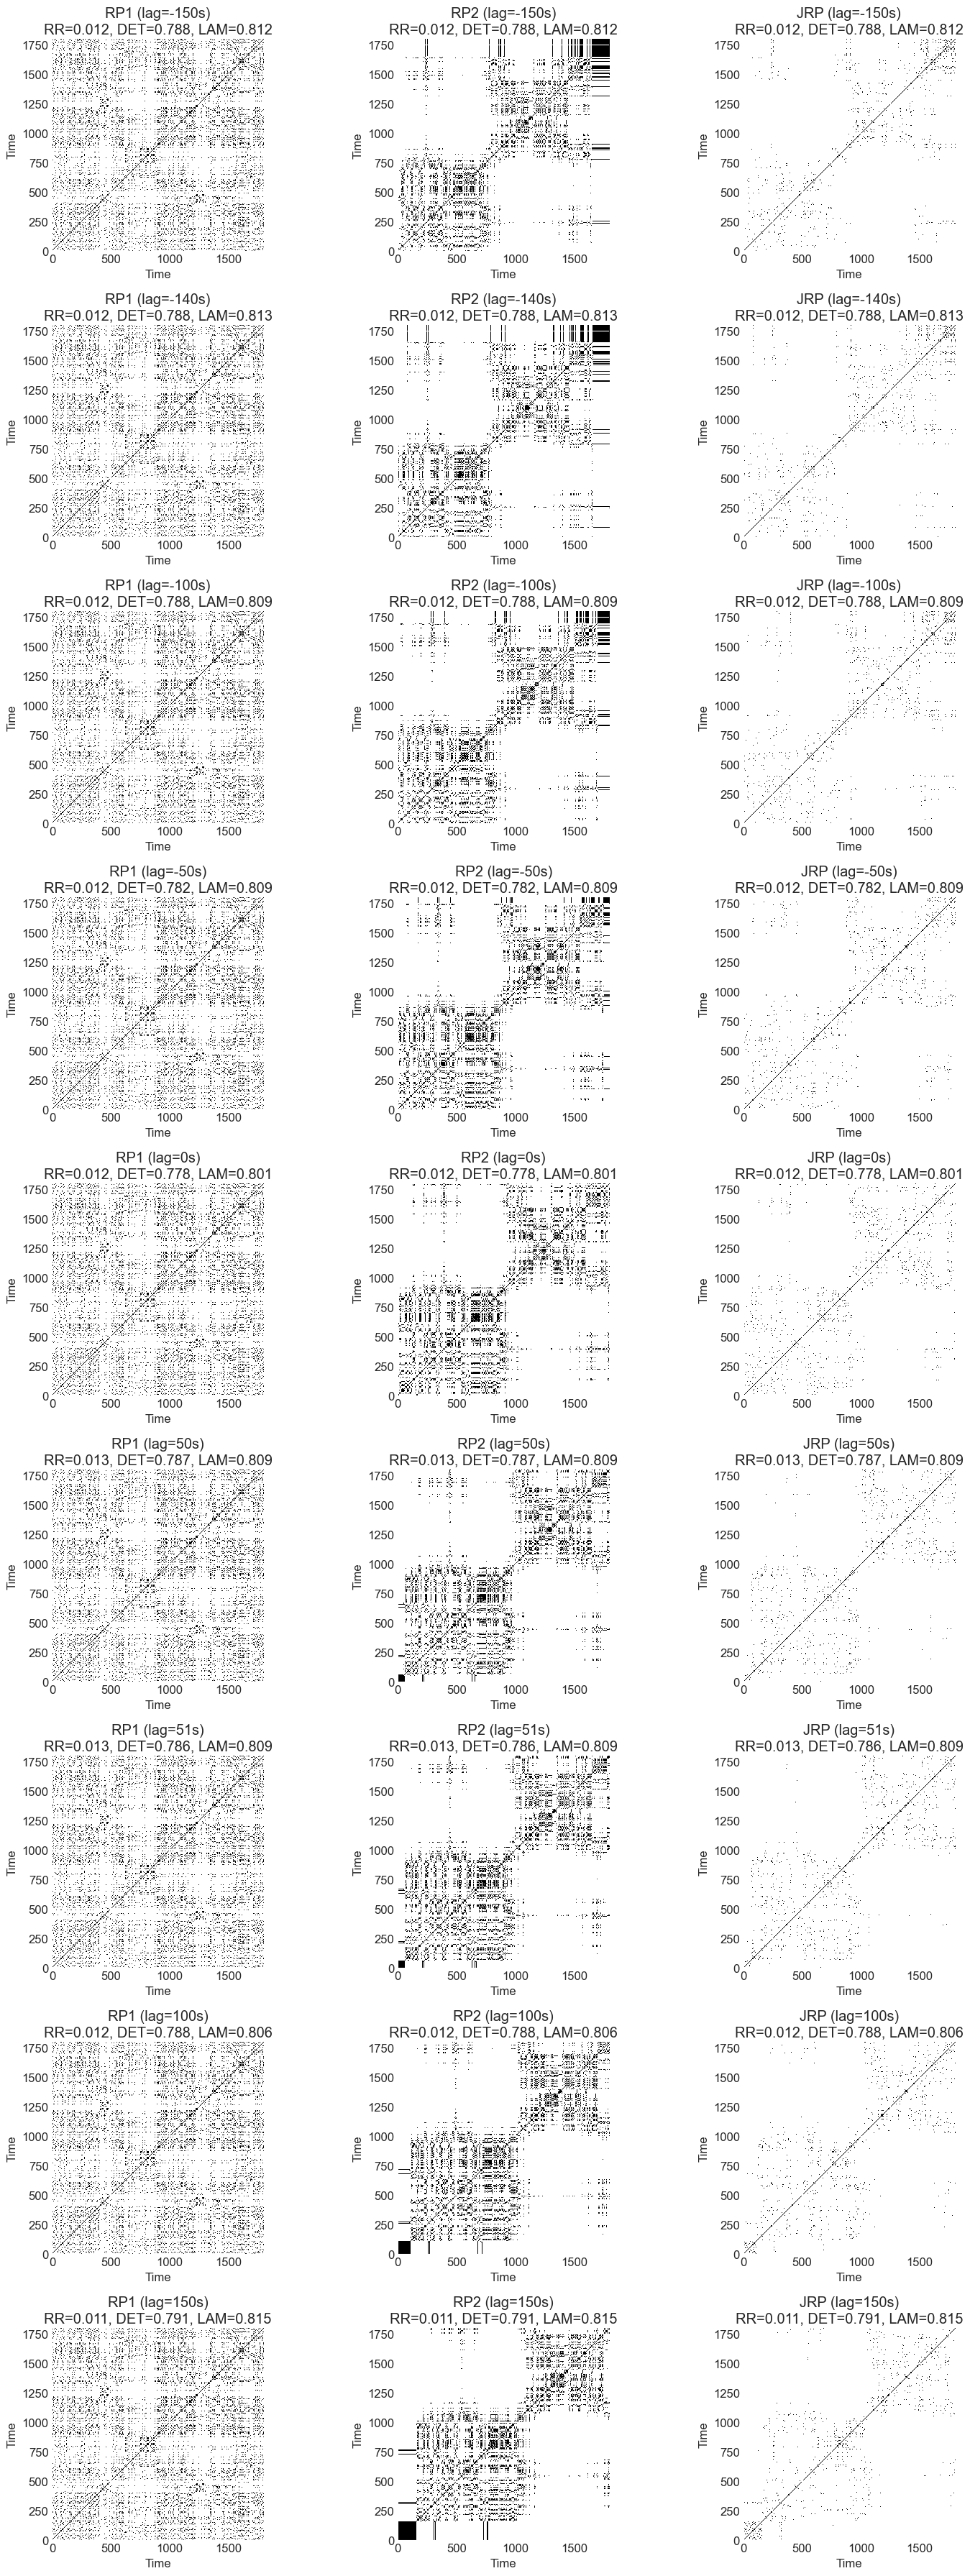

In [29]:
# Detailed JRP visualization at key lags
# Include best Kuramoto lag (max_sustained) and best JRP lag
best_kuramoto_lag = int(results_df.loc[results_df['kuramoto_score'].idxmax(), 'lag'])
best_jrp_lag = int(jrp_valid.loc[jrp_valid['jrp_score'].idxmax(), 'lag']) if len(jrp_valid) > 0 else 0

key_lags = [-150, -100, -50, 0, 50, 100, 150, best_kuramoto_lag, best_jrp_lag]
key_lags = sorted(set([l for l in key_lags if -max_lag <= l <= max_lag]))

fig, axes = plt.subplots(len(key_lags), 3, figsize=(15, 4*len(key_lags)))
if len(key_lags) == 1:
    axes = axes.reshape(1, -1)

for idx, lag in enumerate(key_lags):
    if lag > 0:
        s2_shifted = np.concatenate([np.full(lag, np.nan), s2_smooth[:-lag]])
    elif lag < 0:
        s2_shifted = np.concatenate([s2_smooth[-lag:], np.full(-lag, np.nan)])
    else:
        s2_shifted = s2_smooth.copy()
    s2_shifted = pd.Series(s2_shifted).interpolate(limit_direction='both').values
    
    s1_emb = embed_time_series(s1_smooth, m=m, tau=tau)
    s2_emb = embed_time_series(s2_shifted, m=m, tau=tau)
    min_len = min(len(s1_emb), len(s2_emb))
    
    if min_len > 50:
        rp1, _ = recurrence_plot(s1_emb[:min_len], rate=0.1)
        rp2, _ = recurrence_plot(s2_emb[:min_len], rate=0.1)
        jrp = joint_recurrence_plot(rp1, rp2)
        metrics = jrp_rqa_metrics(jrp)
        
        for ax, rp, title in zip(axes[idx], [rp1, rp2, jrp], 
                                  [f'RP1 (lag={lag}s)', f'RP2 (lag={lag}s)', f'JRP (lag={lag}s)']):
            im = ax.imshow(rp.T, origin='lower', cmap='binary', aspect='equal', interpolation='nearest')
            ax.set_title(f'{title}\nRR={metrics["RR"]:.3f}, DET={metrics["DET"]:.3f}, LAM={metrics["LAM"]:.3f}')
            ax.set_xlabel('Time')
            ax.set_ylabel('Time')
    else:
        for ax in axes[idx]:
            ax.text(0.5, 0.5, 'Too short', ha='center', va='center')

plt.tight_layout()
plt.show()

In [30]:
# JRP at best Kuramoto lag (max_sustained) 
best_kuramoto_lag = int(results_df.loc[results_df['kuramoto_score'].idxmax(), 'lag'])

for lag in [best_kuramoto_lag]:
    if lag > 0:
        s2_shifted = np.concatenate([np.full(lag, np.nan), s2_smooth[:-lag]])
    elif lag < 0:
        s2_shifted = np.concatenate([s2_smooth[-lag:], np.full(-lag, np.nan)])
    else:
        s2_shifted = s2_smooth.copy()
    s2_shifted = pd.Series(s2_shifted).interpolate(limit_direction='both').values
    
    s1_emb = embed_time_series(s1_smooth, m=m, tau=tau)
    s2_emb = embed_time_series(s2_shifted, m=m, tau=tau)
    min_len = min(len(s1_emb), len(s2_emb))
    
    if min_len > 50:
        rp1, _ = recurrence_plot(s1_emb[:min_len], rate=0.05)
        rp2, _ = recurrence_plot(s2_emb[:min_len], rate=0.05)
        jrp = joint_recurrence_plot(rp1, rp2)
        metrics = jrp_rqa_metrics(jrp)
        
        print(f'\n=== Lag = {lag}s ===')
        print(f'  JRP: RR={metrics["RR"]:.4f}, DET={metrics["DET"]:.4f}, LAM={metrics["LAM"]:.4f}')
        print(f'  max_diag={metrics["max_diag"]}, mean_diag={metrics["mean_diag"]:.1f}, max_vert={metrics["max_vert"]}')


=== Lag = 51s ===
  JRP: RR=0.0038, DET=0.7010, LAM=0.6222
  max_diag=1798, mean_diag=3.6, max_vert=9


In [31]:
# Save results
results_df.to_parquet('../data/kuramoto_jrp_lag_sweep_T11_T12.parquet')
print('Saved lag sweep results to ../data/kuramoto_jrp_lag_sweep_T11_T12.parquet')

# Summary
best_kuramoto = int(results_df.loc[results_df['kuramoto_score'].idxmax(), 'lag'])
best_kuramoto_sustained = int(results_df.loc[results_df['kuramoto_score'].idxmax(), 'max_sustained_sec'])
best_kuramoto_frac = results_df.loc[results_df['kuramoto_score'].idxmax(), 'frac_above_07']
best_kuramoto_r = results_df.loc[results_df['kuramoto_score'].idxmax(), 'r_mean']
best_jrp = int(jrp_valid.loc[jrp_valid['jrp_score'].idxmax(), 'lag']) if len(jrp_valid) > 0 else 'N/A'
best_combined = int(results_df.loc[results_df['combined_score'].idxmax(), 'lag'])

print(f'\n=== FINAL SUMMARY ===')
print(f'Best lag (Kuramoto - max_sustained × frac_above_07 × r_mean): {best_kuramoto}s ({best_kuramoto/60:.1f} min)  [max_sustained={best_kuramoto_sustained}s, frac_above_07={best_kuramoto_frac:.3f}, r_mean={best_kuramoto_r:.3f}]')
print(f'Best lag (JRP state sync, excl. extreme lags):           {best_jrp}s ({best_jrp/60 if best_jrp != "N/A" else "N/A"}:.1f min)')
print(f'Best lag (Combined):                                     {best_combined}s ({best_combined/60:.1f} min)')

# Real lag (distance/speed)
lag = int(18600 / df['FormacionVelocidad'].loc[start_time:end_time].mean())
print(f'Real lag (|distance/speed|):                               {lag}s ({lag/60:.1f} min)')

Saved lag sweep results to ../data/kuramoto_jrp_lag_sweep_T11_T12.parquet

=== FINAL SUMMARY ===
Best lag (Kuramoto - max_sustained × frac_above_07 × r_mean): 51s (0.8 min)  [max_sustained=48s, frac_above_07=0.694, r_mean=0.753]
Best lag (JRP state sync, excl. extreme lags):           -140s (-2.3333333333333335:.1f min)
Best lag (Combined):                                     51s (0.8 min)
Real lag (|distance/speed|):                               49s (0.8 min)
